In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

In [2]:
df = pd.read_csv("./customer_churn_realistic.csv")

#### 1. Dataset understanding

In [3]:
df.head()

,age,monthly_charges,total_usage_gb,tenure_months,support_calls,late_payments,gender,contract_type,payment_method,internet_type,region,customer_segment,churn
0,56.0,NaN,222.960092,48.0,13.0,4.0,Male,Quarterly,Net Banking,DSL,North,Premium,No
1,NaN,2295.512167,309.572522,NaN,4.0,5.0,NaN,Monthly,Debit Card,DSL,East,Basic,NaN
2,46.0,NaN,46.314722,35.0,1.0,4.0,Female,Yearly,Debit Card,Fiber,NaN,Standard,Yes
3,NaN,2008.387587,441.796102,86.0,7.0,0.0,Male,Yearly,Credit Card,NaN,South,Standard,Yes
4,60.0,4112.840519,NaN,38.0,13.0,2.0,Female,Quarterly,Net Banking,Mobile,NaN,Basic,No


In [4]:
df.shape

(1300, 13)

In [5]:
df.columns

Index(['age', 'monthly_charges', 'total_usage_gb', 'tenure_months',
       'support_calls', 'late_payments', 'gender', 'contract_type',
       'payment_method', 'internet_type', 'region', 'customer_segment',
       'churn'],
      dtype='str')

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1300 entries, 0 to 1299
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               888 non-null    float64
 1   monthly_charges   991 non-null    float64
 2   total_usage_gb    1090 non-null   float64
 3   tenure_months     1067 non-null   float64
 4   support_calls     1109 non-null   float64
 5   late_payments     1032 non-null   float64
 6   gender            963 non-null    str    
 7   contract_type     1133 non-null   str    
 8   payment_method    951 non-null    str    
 9   internet_type     1130 non-null   str    
 10  region            993 non-null    str    
 11  customer_segment  869 non-null    str    
 12  churn             986 non-null    str    
dtypes: float64(6), str(7)
memory usage: 132.2 KB


In [ ]:
df.isnull().sum() # List of null values column-wise

age                 412
monthly_charges     309
total_usage_gb      210
tenure_months       233
support_calls       191
late_payments       268
gender              337
contract_type       167
payment_method      349
internet_type       170
region              307
customer_segment    431
churn               314
dtype: int64

In [ ]:
df.isnull().sum().sum() # Total Null values check

np.int64(3698)

In [ ]:
df.duplicated().sum() # Duplicate rows check

np.int64(0)

In [14]:
df.describe()

,age,monthly_charges,total_usage_gb,tenure_months,support_calls,late_payments
count,888.000000,991.000000,1090.000000,1067.000000,1109.000000,1032.000000
mean,43.780405,2751.009143,254.621639,60.040300,6.904418,4.531008
std,15.066638,1305.896643,143.745770,33.975342,4.301988,2.938920
min,18.000000,520.844104,5.005759,1.000000,0.000000,0.000000
25%,31.000000,1574.540054,135.861147,30.000000,3.000000,2.000000
50%,44.000000,2806.261919,256.081717,60.000000,7.000000,5.000000
75%,56.000000,3861.065665,377.738806,88.000000,11.000000,7.000000
max,69.000000,4990.703497,498.921324,119.000000,14.000000,9.000000


In [19]:
dfcpy = df.copy() # Creating a copy of the database to keep the original intact

#### 2. Handling the missing values

In [ ]:
dfcpy["age"] = dfcpy["age"].fillna(df["age"].mean())

dfcpy["age"].isnull().sum()

#Age filled with mean because fairly distributed and no possible outliers

np.int64(0)

In [ ]:
dfcpy["monthly_charges"] = dfcpy["monthly_charges"].fillna(df["monthly_charges"].median())

dfcpy["monthly_charges"].isnull().sum()

#Monthly Charges filled with median because fairly distributed and no possible outliers seen but can be

np.int64(0)

In [37]:
dfcpy["total_usage_gb"] = dfcpy["total_usage_gb"].fillna(df["total_usage_gb"].median())

dfcpy["total_usage_gb"].isnull().sum()

#Total Used GB filled with median because fairly distributed and no possible outliers seen but can be

np.int64(0)

In [32]:
dfcpy["tenure_months"] = dfcpy["tenure_months"].fillna(dfcpy["tenure_months"].median())

dfcpy["tenure_months"].isnull().sum()

#Tenure Months filled with median because fairly distributed and no possible outliers seen but can be

np.int64(0)

In [33]:
dfcpy["support_calls"] = dfcpy["support_calls"].fillna(dfcpy["support_calls"].median())

dfcpy["support_calls"].isnull().sum()

#Tenure Months filled with median because fairly distributed and no possible outliers seen but can be

np.int64(0)

In [34]:
dfcpy["late_payments"] = dfcpy["late_payments"].fillna(dfcpy["late_payments"].median())

dfcpy["late_payments"].isnull().sum()

#Tenure Months filled with median because fairly distributed and no possible outliers seen but can be

np.int64(0)

In [38]:
# Now chckiing if the dataset has any numerically missing values (Not category or string), or all the values are filled. 
# Didnt drop any because there were too many missing values compared to the total values in dataset

dfcpy.isnull().sum()

age                   0
monthly_charges       0
total_usage_gb        0
tenure_months         0
support_calls         0
late_payments         0
gender              337
contract_type       167
payment_method      349
internet_type       170
region              307
customer_segment    431
churn               314
dtype: int64

In [ ]:
dfcpy["gender"] = dfcpy["gender"].fillna(dfcpy["gender"].mode()[0])

dfcpy["gender"].isnull().sum()

#Gender filled with mode as it is a categorical data

np.int64(0)

In [ ]:
dfcpy["contract_type"] = dfcpy["contract_type"].fillna(dfcpy["contract_type"].mode()[0])

dfcpy["contract_type"].isnull().sum()

#Contract Type filled with mode as it is a categorical data

np.int64(0)

In [ ]:
dfcpy["payment_method"] = dfcpy["payment_method"].fillna(dfcpy["payment_method"].mode()[0])

dfcpy["payment_method"].isnull().sum()

#Payment Method filled with mode as it is a categorical data

np.int64(0)

In [42]:
dfcpy["internet_type"] = dfcpy["internet_type"].fillna(dfcpy["internet_type"].mode()[0])

dfcpy["internet_type"].isnull().sum()

#Internet Type filled with mode as it is a categorical data

np.int64(0)

In [43]:
dfcpy["region"] = dfcpy["region"].fillna(dfcpy["region"].mode()[0])

dfcpy["region"].isnull().sum()

#Region filled with mode as it is a categorical data

np.int64(0)

In [44]:
dfcpy["customer_segment"] = dfcpy["customer_segment"].fillna(dfcpy["customer_segment"].mode()[0])

dfcpy["customer_segment"].isnull().sum()

#Customer Segment filled with mode as it is a categorical data

np.int64(0)

In [45]:
dfcpy["churn"] = dfcpy["churn"].fillna(dfcpy["churn"].mode()[0])

dfcpy["churn"].isnull().sum()

#Churn filled with mode as it is a categorical data

np.int64(0)

In [46]:
# Now chckiing if the dataset has any missing values at all or all the values are filled. 
# Didnt drop any because there were too many missing values compared to the total values in dataset

dfcpy.isnull().sum()

age                 0
monthly_charges     0
total_usage_gb      0
tenure_months       0
support_calls       0
late_payments       0
gender              0
contract_type       0
payment_method      0
internet_type       0
region              0
customer_segment    0
churn               0
dtype: int64

#### 3 Outliers Detection

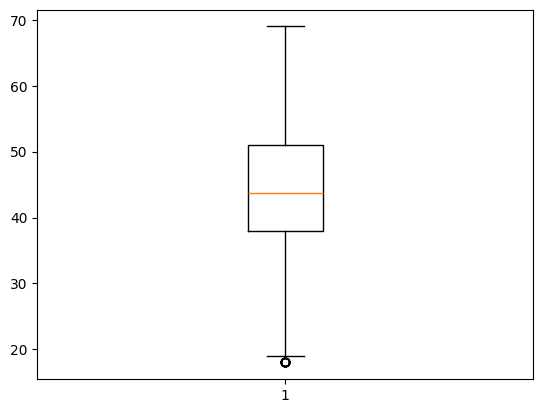

In [48]:
plt.boxplot(dfcpy["age"])
plt.show()

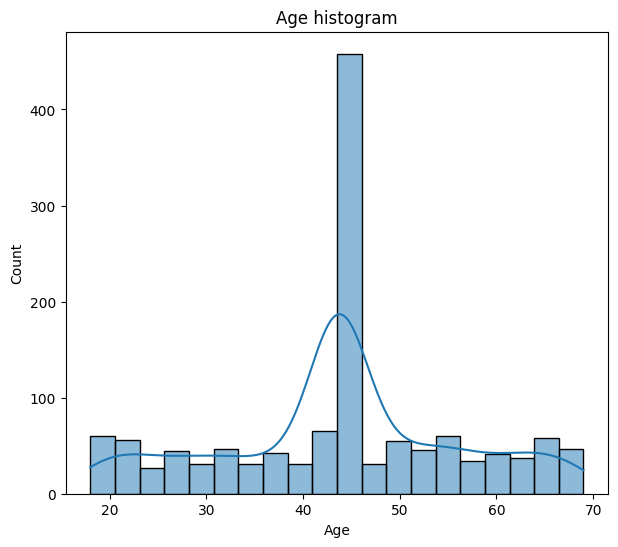

In [52]:
plt.figure(figsize=(7,6))

sns.histplot(data=dfcpy, x="age", kde=True, bins=20)
plt.title("Age histogram")
plt.xlabel("Age")
plt.ylabel("Count")

plt.show()

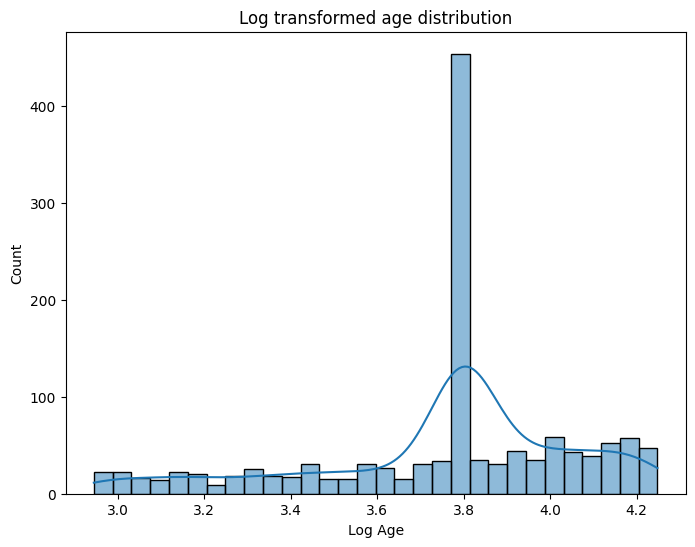

In [66]:
#log distribution off age
plt.figure(figsize=(8,6))

sns.histplot(x=np.log1p(dfcpy["age"]), kde=True, bins=30)
plt.title("Log transformed age distribution")
plt.xlabel("Log Age")
plt.ylabel("Count")

plt.show()

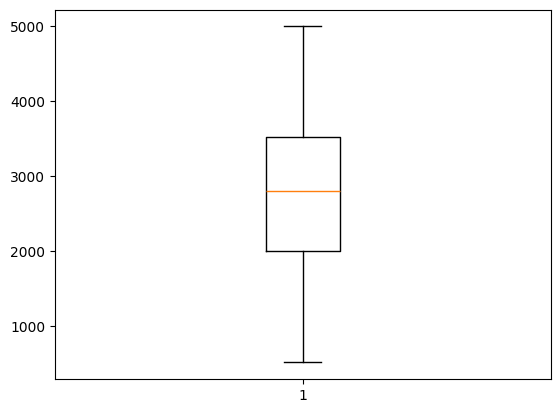

In [55]:
plt.boxplot(dfcpy["monthly_charges"])
plt.show()

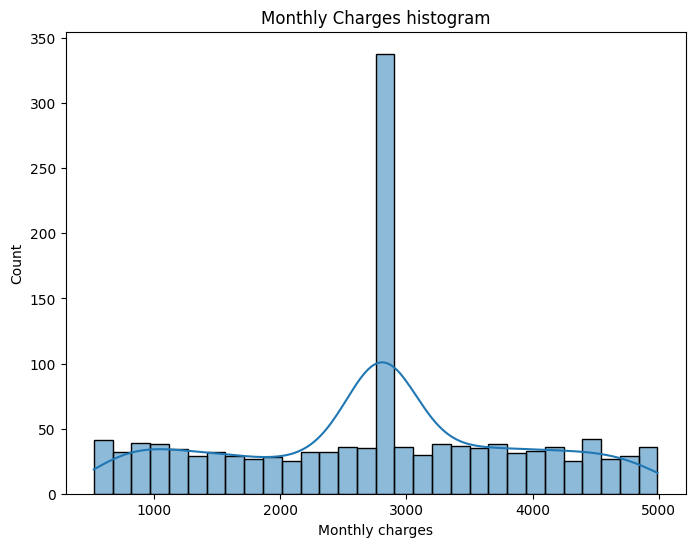

In [56]:
plt.figure(figsize=(8,6))

sns.histplot(data=dfcpy, x="monthly_charges", kde=True, bins=30)
plt.title("Monthly Charges histogram")
plt.xlabel("Monthly charges")
plt.ylabel("Count")

plt.show()


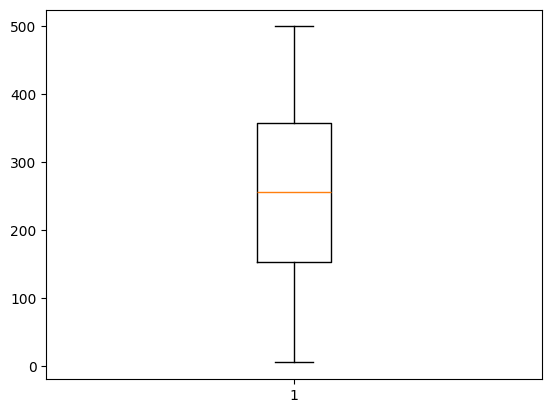

In [58]:
plt.boxplot(dfcpy["total_usage_gb"])
plt.show()

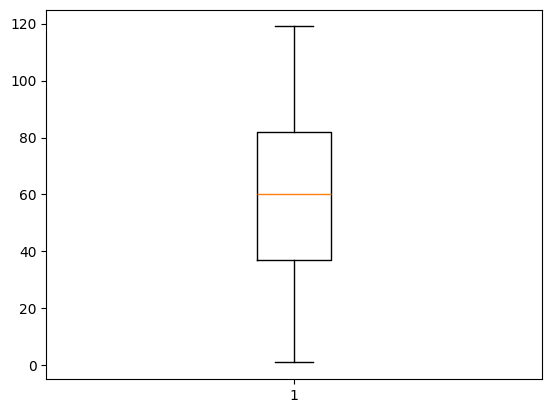

In [59]:
plt.boxplot(dfcpy["tenure_months"])
plt.show()

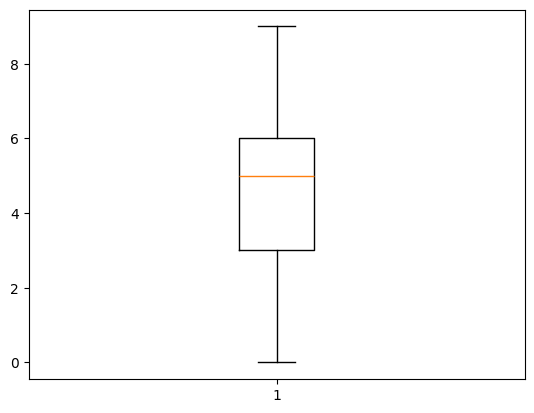

In [60]:
plt.boxplot(dfcpy["late_payments"])
plt.show()

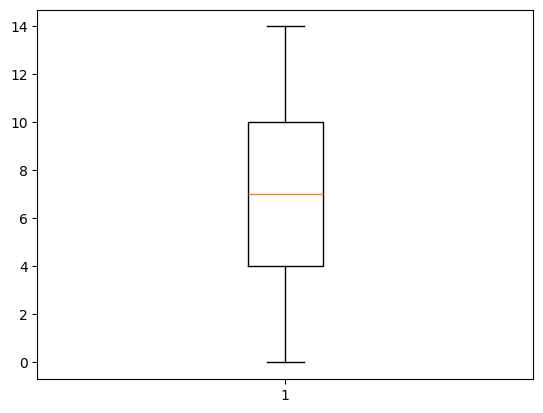

In [61]:
plt.boxplot(dfcpy["support_calls"])
plt.show()

#### 4. Univariate analysis of categorial columns

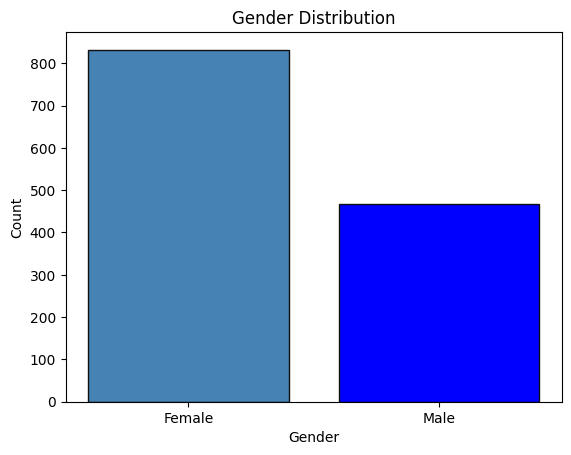

In [71]:
gender_count = dfcpy["gender"].value_counts() 

plt.bar(gender_count.index, gender_count.values, color=["steelblue", "blue"], edgecolor="#101010")
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.show()

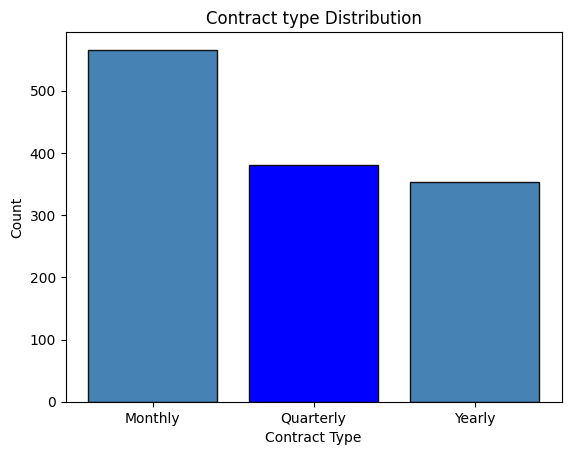

In [70]:
gender_count = dfcpy["contract_type"].value_counts() 

plt.bar(gender_count.index, gender_count.values, color=["steelblue", "blue"], edgecolor="#101010")
plt.title("Contract type Distribution")
plt.xlabel("Contract Type")
plt.ylabel("Count")

plt.show()

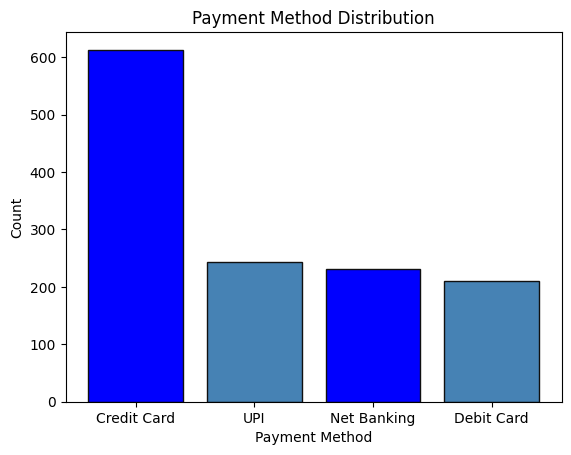

In [73]:
payment_count = dfcpy["payment_method"].value_counts()

plt.bar(payment_count.index, payment_count.values, color=["blue", "steelblue"], edgecolor="#101010")
plt.title("Payment Method Distribution")
plt.xlabel("Payment Method")
plt.ylabel("Count")

plt.show()

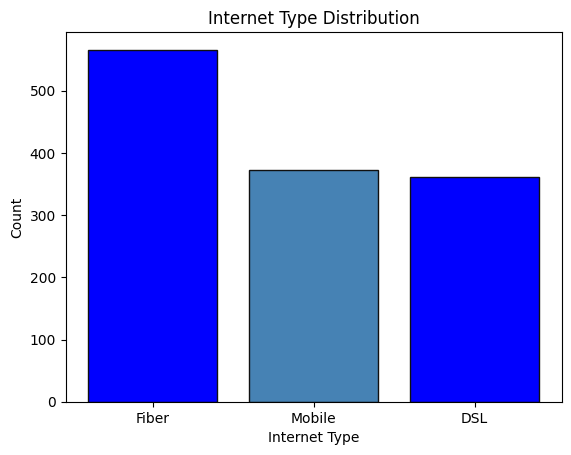

In [74]:
payment_count = dfcpy["internet_type"].value_counts()

plt.bar(payment_count.index, payment_count.values, color=["blue", "steelblue"], edgecolor="#101010")
plt.title("Internet Type Distribution")
plt.xlabel("Internet Type")
plt.ylabel("Count")

plt.show()

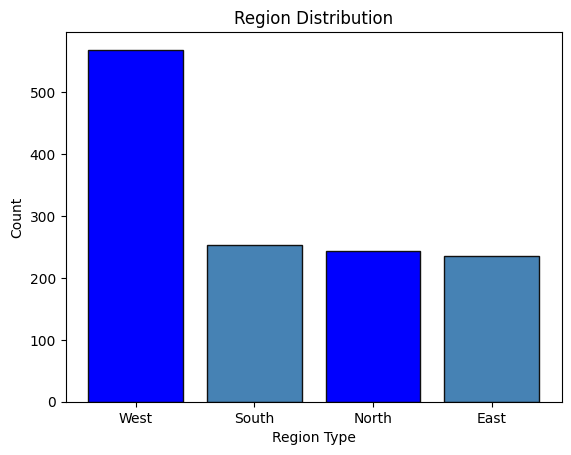

In [75]:
payment_count = dfcpy["region"].value_counts()

plt.bar(payment_count.index, payment_count.values, color=["blue", "steelblue"], edgecolor="#101010")
plt.title("Region Distribution")
plt.xlabel("Region Type")
plt.ylabel("Count")

plt.show()

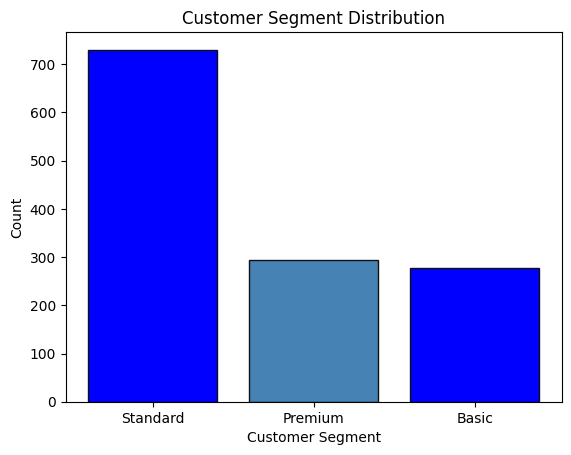

In [77]:
payment_count = dfcpy["customer_segment"].value_counts()

plt.bar(payment_count.index, payment_count.values, color=["blue", "steelblue"], edgecolor="#101010")
plt.title("Customer Segment Distribution")
plt.xlabel("Customer Segment")
plt.ylabel("Count")

plt.show()

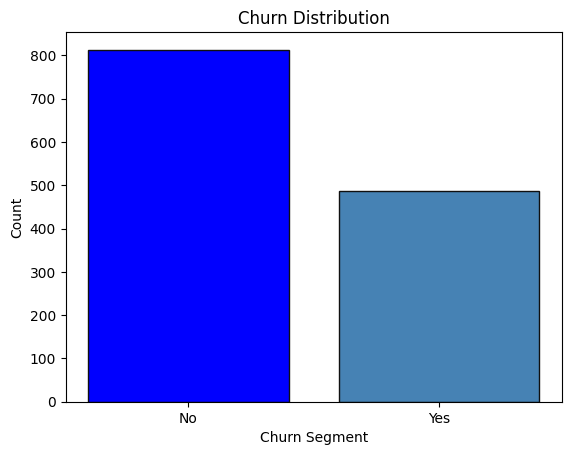

In [78]:
payment_count = dfcpy["churn"].value_counts()

plt.bar(payment_count.index, payment_count.values, color=["blue", "steelblue"], edgecolor="#101010")
plt.title("Churn Distribution")
plt.xlabel("Churn Segment")
plt.ylabel("Count")

plt.show()

#### 5. Corelation discovery

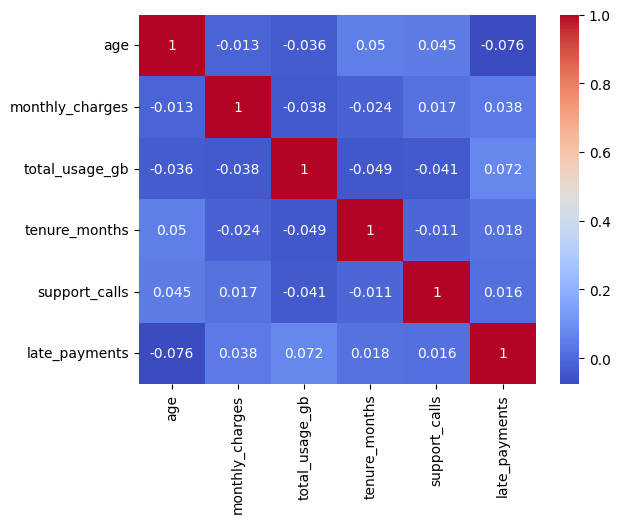

In [82]:
# grouping numerical columns and then potting their heatmap cause only numerical value be used in corr()

numeric_df = df.select_dtypes(include=["int64", "float64"])

corr_matrix = numeric_df.corr()

sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.show()

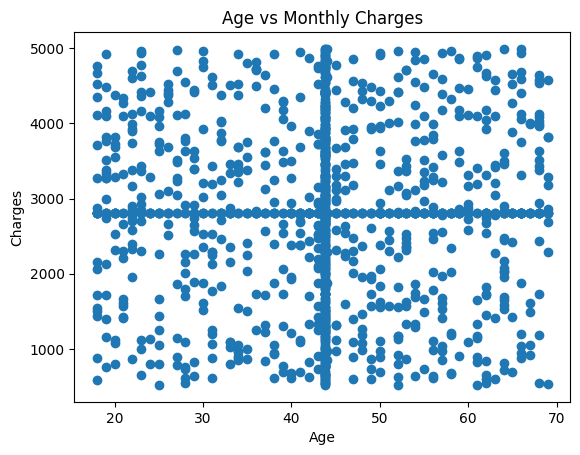

In [90]:
plt.scatter(dfcpy["age"], dfcpy["monthly_charges"])
plt.title("Age vs Monthly Charges")
plt.xlabel("Age")
plt.ylabel("Charges")
plt.show()

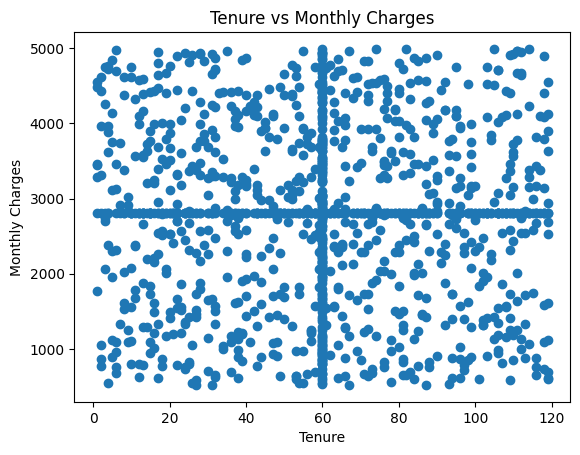

In [89]:
plt.scatter(dfcpy["tenure_months"], dfcpy["monthly_charges"])
plt.title("Tenure vs Monthly Charges")
plt.xlabel("Tenure")
plt.ylabel("Monthly Charges")
plt.show()

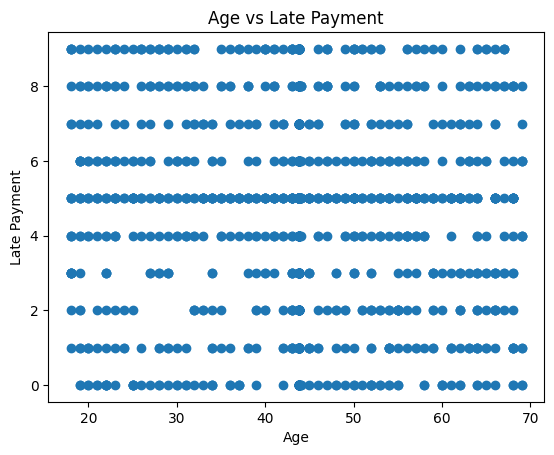

In [88]:
plt.scatter(dfcpy["age"], dfcpy["late_payments"])
plt.title("Age vs Late Payment")
plt.xlabel("Age")
plt.ylabel("Late Payment")
plt.show()

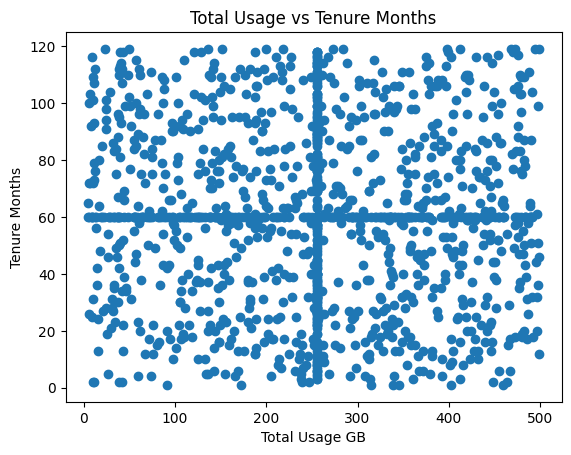

In [87]:
plt.scatter(dfcpy["total_usage_gb"], dfcpy["tenure_months"])
plt.title("Total Usage vs Tenure Months")
plt.xlabel("Total Usage GB")
plt.ylabel("Tenure Months")
plt.show()

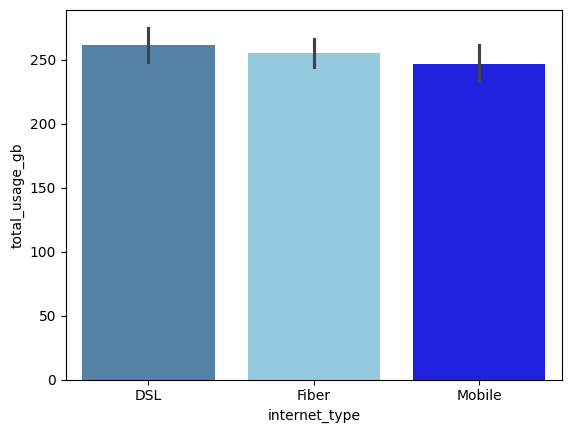

In [99]:
sns.barplot(
    data=dfcpy,
    x="internet_type",
    y="total_usage_gb",
    hue="internet_type",
    estimator=np.mean,
    palette={"Mobile": "blue", "DSL": "steelblue", "Fiber": "skyblue"},
    legend=False
)

plt.show()

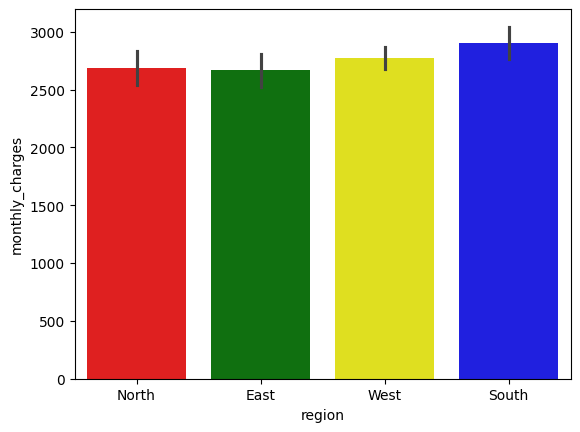

In [100]:
sns.barplot(
    data=dfcpy,
    x="region",
    y="monthly_charges",
    hue="region",
    estimator=np.mean,
    palette={ "North": "red", "South": "blue", "East": "green", "West": "yellow" },
    legend=False
)

plt.show()

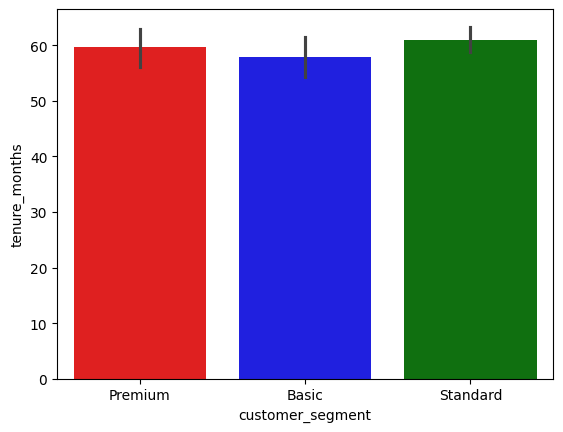

In [102]:
sns.barplot(
    data=dfcpy,
    x="customer_segment",
    y="tenure_months",
    hue="customer_segment",
    estimator=np.mean,
    palette={ "Premium": "red", "Basic": "blue", "Standard": "green" },
    legend=False
)

plt.show()

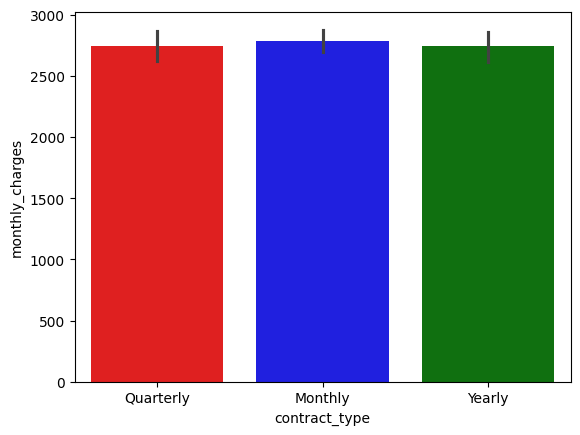

In [103]:
sns.barplot(
    data=dfcpy,
    x="contract_type",
    y="monthly_charges",
    hue="contract_type",
    estimator=np.mean,
    palette={ "Quarterly": "red", "Monthly": "blue", "Yearly": "green" },
    legend=False
)

plt.show()

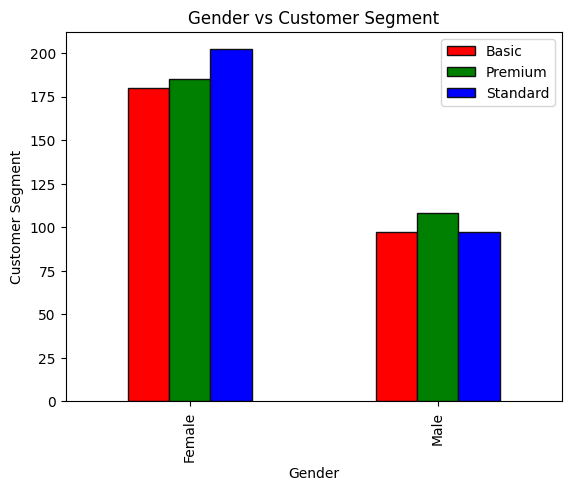

In [108]:
#gender vs customer segment

gender_segment = pd.crosstab(dfcpy["gender"], df["customer_segment"])

gender_segment.plot(kind="bar", stacked=False, color=["red", "green", "blue"], edgecolor="#101010")
plt.title("Gender vs Customer Segment")
plt.xlabel("Gender")
plt.ylabel("Customer Segment")
plt.legend(["Basic", "Premium", "Standard"])
plt.show()

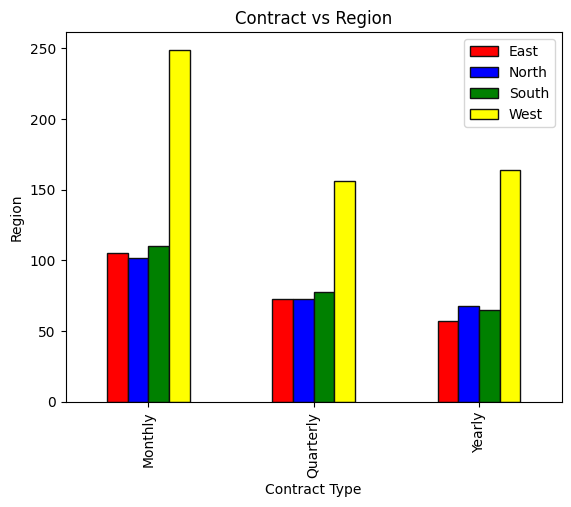

In [114]:
contract_region = pd.crosstab(dfcpy["contract_type"], dfcpy["region"])

contract_region.plot(
    kind="bar",
    stacked=False,
    color=["red", "blue", "green", "yellow"],
    edgecolor="#101010"
)

plt.title("Contract vs Region")
plt.xlabel("Contract Type")
plt.ylabel("Region")
plt.legend(["East", "North", "South", "West"])
plt.show()

#### 6. Multivariate analysis

<Figure size 1000x1200 with 0 Axes>

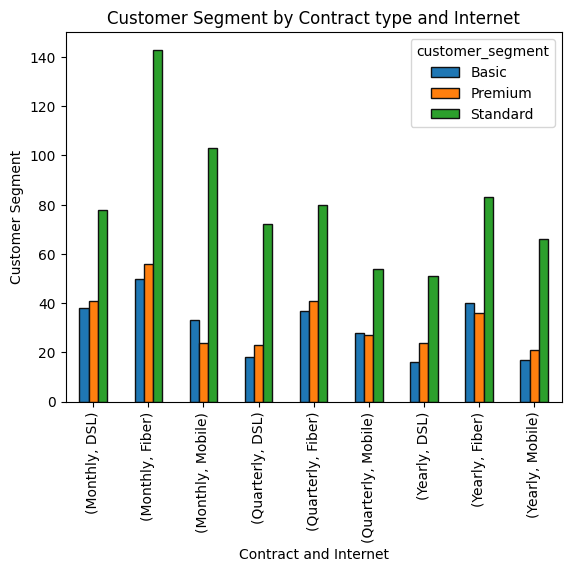

In [119]:
contract_internet_customer = pd.crosstab([dfcpy["contract_type"], dfcpy["internet_type"]], dfcpy["customer_segment"])

plt.figure(figsize=(10,12))

contract_internet_customer.plot(
    kind="bar",
    stacked=False,
    edgecolor="#101010"
)
plt.title("Customer Segment by Contract type and Internet")
plt.xlabel("Contract and Internet")
plt.ylabel("Customer Segment")
plt.show()

<Figure size 1000x1200 with 0 Axes>

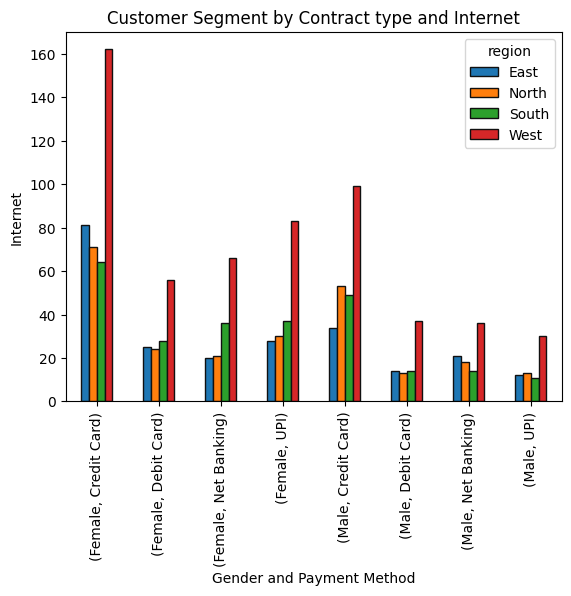

In [123]:
monthly_total_internet = pd.crosstab([dfcpy["gender"], dfcpy["payment_method"]], dfcpy["region"])

plt.figure(figsize=(10,12))

monthly_total_internet.plot(
    kind="bar",
    stacked=False,
    edgecolor="#101010"
)
plt.title("Customer Segment by Contract type and Internet")
plt.xlabel("Gender and Payment Method")
plt.ylabel("Internet")
plt.show()